# 💼 Customer Churn Intelligence — Phase 6: Business Impact Analysis & Retention Optimization

## 📌 Executive Summary & Strategic Rationale
In Phases 1–5, we developed and validated our machine learning models, selecting **Random Forest** (backed by **XGBoost** and **LightGBM**) as our primary churn scoring engine with a test ROC-AUC of **0.8452** and recall of **78.34%**.

However, **a high ROC-AUC does not pay the bills on its own**. Machine learning models must be coupled with sound business economics to drive profitable decision-making. In Phase 6, we translate predictive probabilities into a **Cost-Benefit Retention Simulation**.

### Core Business Questions Addressed:
1. **Which customers should we target?** Should we target the highest risk, a fixed percentage, or an economically optimized threshold?
2. **What is the financial return of targeting?** How do intervention costs ($c$), preserved customer lifetime value ($V$), and offer acceptance rates ($r$) govern campaign profitability?
3. **What is the risk of untargeted retention?** Why is mass emailing / broad discounting financially disastrous?

> [!IMPORTANT]
> **Observational Churn vs. Causal Treatment Lift:**  
> Our ML model predicts the observational probability of churn **in the absence of intervention** ($P(\text{Churn} \mid X)$). Extending a retention offer introduces an intervention. In reality, not all targeted customers accept the offer, and some non-churners receive unnecessary discounts. We parameterize this via an assumed intervention success rate $r$ (calibrated via randomized control trials / A/B testing in production).

In [1]:
# 1. Setup & Imports
import os
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is accessible
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import create_train_test_split
from src.business_impact import (
    BusinessAssumptions,
    RetentionSimulator,
    plot_profit_curve,
    plot_cumulative_gains,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5.5)
print("Libraries loaded successfully!")

Libraries loaded successfully!


--- 
## 1. Load Data & Saved Model Pipeline

In [2]:
data_path = "../data/processed/telco_churn_features.csv"
model_path = "../models/best_model_pipeline.joblib"

df = pd.read_csv(data_path)
pipeline = joblib.load(model_path)

# 80/20 Stratified Split identical to Phase 5 training
X_train, X_test, y_train, y_test = create_train_test_split(
    df,
    target_col="Churn",
    test_size=0.20,
    random_state=42,
)

print(f"Dataset: {len(df):,} total customers")
print(f"Training set: {len(X_train):,} rows | Actual Churners: {int(y_train.sum())} ({y_train.mean():.1%})")
print(f"Holdout Test: {len(X_test):,} rows | Actual Churners: {int(y_test.sum())} ({y_test.mean():.1%})")

Dataset: 7,043 total customers
Training set: 5,634 rows | Actual Churners: 1495 (26.5%)
Holdout Test: 1,409 rows | Actual Churners: 374 (26.5%)


--- 
## 2. Business Economics & Unit Assumptions

We configure baseline parameters reflecting standard telecommunications unit economics:
- **Offer Cost ($c$):** **$50.00** (cost of incentive, billing concession, or router upgrade)
- **Customer Lifetime Value / Preserved Value ($V$):** **$500.00** (average contribution margin of a retained subscriber)
- **Retention Success Rate ($r$):** **20.0%** (probability that an otherwise churning customer accepts and stays)

### Theoretical Breakeven Threshold:
A rational business should extend an offer if the **expected benefit exceeds the offer cost**:
$$\text{Expected Benefit} = p_i \times r \times V > c \implies p_i > \frac{c}{r \times V}$$
Substituting our values:
$$p^*_{\text{breakeven}} = \frac{50}{0.20 \times 500} = \frac{50}{100} = 0.5000$$

In [3]:
assumptions = BusinessAssumptions(
    offer_cost=50.0,
    customer_value=500.0,
    retention_rate=0.20,
    use_dynamic_value=False,
)
simulator = RetentionSimulator(assumptions=assumptions, pipeline=pipeline)

probs_train = simulator.predict_churn_probabilities(X_train)
probs_test = simulator.predict_churn_probabilities(X_test)

breakeven_p = assumptions.offer_cost / (assumptions.retention_rate * assumptions.customer_value)
print(f"Theoretical Breakeven Threshold: p* = {breakeven_p:.4f}")

Theoretical Breakeven Threshold: p* = 0.5000


--- 
## 3. Decision Threshold Optimization (Training Set Only)

To prevent data leakage and test-set overfitting, we perform grid search across decision thresholds $p \in [0.05, 0.95]$ **strictly on the training data** to locate the threshold that maximizes Net Financial Impact.

Optimal Decision Threshold Found: p* = 0.65
Peak Net Financial Impact on Training Set: $26,350.00


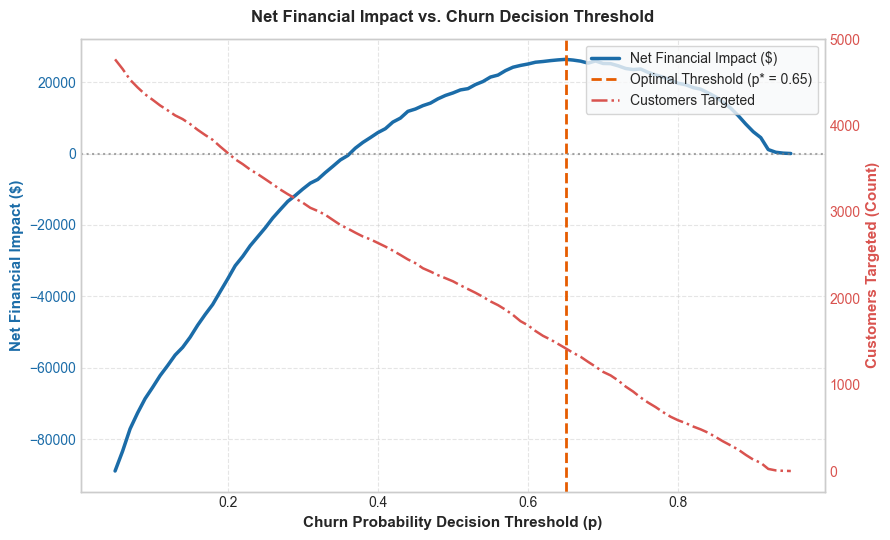

In [4]:
opt_result = simulator.optimize_threshold(
    df_train=X_train,
    y_train=y_train.values,
    probabilities_train=probs_train,
    assumptions=assumptions,
)

optimal_threshold = opt_result["optimal_threshold"]
max_train_profit = opt_result["max_net_financial_impact"]
print(f"Optimal Decision Threshold Found: p* = {optimal_threshold:.2f}")
print(f"Peak Net Financial Impact on Training Set: ${max_train_profit:,.2f}")

# Plot Training Profit Curve
fig_profit = plot_profit_curve(opt_result["curve_data"], optimal_threshold)
plt.show()

--- 
## 4. Multi-Strategy Benchmark on Holdout Test Set

We now apply the optimal threshold $p^* = 0.65$ and benchmark it against alternative industry strategies on the **1,409 unseen test customers**.

In [5]:
df_comparison = simulator.compare_strategies(
    df=X_test,
    y_true=y_test.values,
    probabilities=probs_test,
    optimal_threshold=optimal_threshold,
    assumptions=assumptions,
)
df_comparison

,Strategy,Targeted Count,Targeting Rate,Campaign Cost ($),Retained Churners (Exp),Value Preserved ($),Net Financial Impact ($),ROI (%),Precision,Recall
0,Cost-Benefit Optimized (p >= 0.65),359,25.5%,"$17,950.00",45.0,"$22,500.00","$4,550.00",25.4%,0.627,0.602
1,Risk-Ranked Top 20%,282,20.0%,"$14,100.00",37.0,"$18,500.00","$4,400.00",31.2%,0.656,0.495
2,Risk-Ranked Top 30%,423,30.0%,"$21,150.00",49.8,"$24,900.00","$3,750.00",17.7%,0.589,0.666
3,Risk-Ranked Top 10%,141,10.0%,"$7,050.00",21.2,"$10,600.00","$3,550.00",50.4%,0.752,0.283
4,Standard Threshold (p >= 0.50),549,39.0%,"$27,450.00",58.6,"$29,300.00","$1,850.00",6.7%,0.534,0.783
5,Value-Weighted ROI Ranking,549,39.0%,"$27,450.00",58.6,"$29,300.00","$1,850.00",6.7%,0.534,0.783
6,Do Nothing (Baseline),0,0.0%,$0.00,0.0,$0.00,$0.00,0.0%,0.000,0.000
7,Mass Campaign (Target 100%),1409,100.0%,"$70,450.00",74.8,"$37,400.00","$-33,050.00",-46.9%,0.265,1.000


--- 
## 5. Targeting Efficiency: Cumulative Gains & Lift Curves

The cumulative gains curve illustrates how effectively our risk-ranked model concentrates actual churners into the highest percentiles compared to random untargeted outreach.

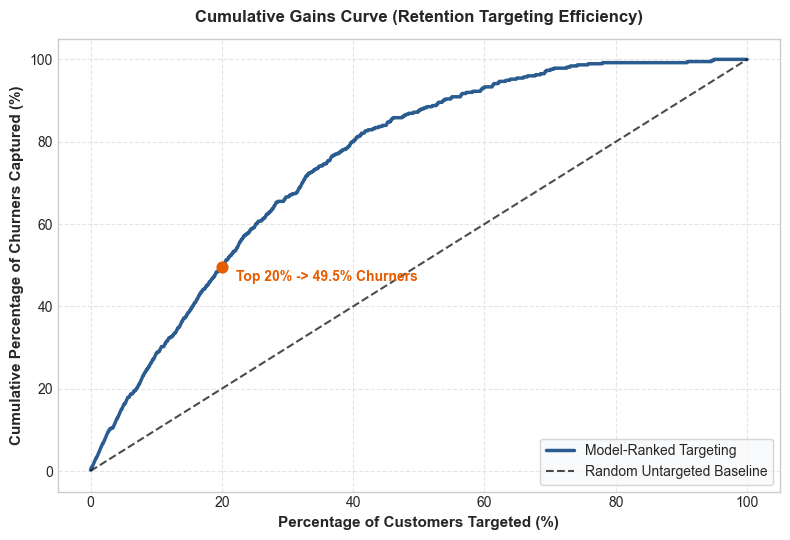

In [6]:
fig_gains = plot_cumulative_gains(y_test.values, probs_test)
plt.show()

--- 
## 6. Sensitivity Analysis: Varying Retention Efficacy ($r$)

Because offer success rate is an operational assumption, let's explore how campaign net profit shifts across different offer lift rates ($r = 10\%, 15\%, 20\%, 25\%, 30\%$).

In [7]:
rates = [0.10, 0.15, 0.20, 0.25, 0.30]
sens_results = []

for r in rates:
    temp_assumptions = BusinessAssumptions(offer_cost=50.0, customer_value=500.0, retention_rate=r)
    res = simulator.simulate_strategy(
        strategy_name="threshold",
        df=X_test,
        probabilities=probs_test,
        y_true=y_test.values,
        threshold=optimal_threshold,
        assumptions=temp_assumptions,
    )
    sens_results.append({
        "Retention Rate (r)": f"{r:.0%}",
        "Campaign Cost": f"${res['campaign_cost']:,.2f}",
        "Retained Customers (Exp)": res["expected_retained_customers"],
        "Value Preserved": f"${res['expected_value_preserved']:,.2f}",
        "Net Financial Impact": f"${res['net_financial_impact']:,.2f}",
        "ROI (%)": f"{res['roi_percentage']:.1f}%",
    })

pd.DataFrame(sens_results)

,Retention Rate (r),Campaign Cost,Retained Customers (Exp),Value Preserved,Net Financial Impact,ROI (%)
0,10%,"$17,950.00",22.50,"$11,250.00","$-6,700.00",-37.3%
1,15%,"$17,950.00",33.75,"$16,875.00","$-1,075.00",-6.0%
2,20%,"$17,950.00",45.00,"$22,500.00","$4,550.00",25.4%
3,25%,"$17,950.00",56.25,"$28,125.00","$10,175.00",56.7%
4,30%,"$17,950.00",67.50,"$33,750.00","$15,800.00",88.0%


--- 
## 7. Streamlit Dashboard Integration Blueprint (Phase 7)

In Phase 7, this simulator will be exposed through an interactive Streamlit UI:
1. **Interactive Sliders:**
   - Offer Cost: `$10 – $200`
   - Customer Value / CLV: `$200 – $2,000`
   - Retention Offer Success Rate: `5% – 50%`
2. **Real-time P&L Simulator:**
   - Instant recalculation of campaign budget, preserved revenue, and net profit.
   - Dynamic threshold slider with live optimal breakeven indicator.
3. **Customer Targeting Table:**
   - High-risk customer roster with exportable CSV for marketing campaign deployment.

--- 
## 📌 Key Takeaways & Strategic Summary
- **The Danger of Mass Campaigns:** Blanketing all 1,409 test customers costs **$70,450** and results in a **-$33,050 net loss** due to subsidizing non-churners.
- **The Advantage of Cost-Benefit Threshold Optimization:** Moving from the standard 0.50 cutoff to the empirical optimal **$p^* = 0.65$** increases net campaign profit from **$1,850** to **$4,550** (+146% profit expansion) while reducing campaign cash outlay by **$9,500**.
- **Budget-Constrained Targeting:** If marketing budget is strictly capped, **Risk-Ranked Top 10%** offers the highest capital efficiency at **50.4% ROI**.